In [ ]:
import pandas as pd

# Load dataset
df = pd.read_csv("../data/processed/final_merged.csv")

# Basic inspection
print("Shape:", df.shape)
print("\nColumns:\n", df.columns)

df.head()

In [ ]:
# Dataset structure analysis

print("Dataset Shape:", df.shape)

print("\nColumn Names:")
for col in df.columns:
    print("-", col)

print("\nData Types:")
print(df.dtypes)

print("\nBasic Info:")
df.info()

In [ ]:
# Summary Statistics 
print("\nSummary Statistics:")
print(df.describe())


In [ ]:
# Identify Key Variables    
target_variable = "electricity_demand_per_capita"

key_features = [
    "temperature_change_c",
    "co2_per_capita",
    "gdp",
    "population",
    "renewables_share_elec",
    "fossil_share_elec"
]

print("Target Variable:", target_variable)
print("Key Features:", key_features)

In [ ]:
# Check missing values
missing_df = (df.isnull().sum() / len(df)) * 100
print(missing_df.sort_values(ascending=False))

In [ ]:
# Check duplicate records based on country-year

duplicate_count = df.duplicated(subset=["country", "year"]).sum()

print("Duplicate country-year records:", duplicate_count)

duplicate_rows = df[df.duplicated(subset=["country", "year"], keep=False)]

print("\nDuplicate Rows:")
display(duplicate_rows)

In [ ]:
# Validate country and year consistency

print("Country missing values:", df["country"].isnull().sum())
print("Year missing values:", df["year"].isnull().sum())

print("\nYear data type:", df["year"].dtype)
print("Minimum year:", df["year"].min())
print("Maximum year:", df["year"].max())

invalid_years = df[(df["year"] < 1990) | (df["year"] > 2024)]
print("\nInvalid year records:", len(invalid_years))

blank_countries = df[df["country"].astype(str).str.strip() == ""]
print("Blank country records:", len(blank_countries))

unique_countries = df["country"].nunique()
print("Unique countries:", unique_countries)

# Trend Analysis of Energy Demand

For initial exploration and data validation in US-1 and US-2, the project used the `final_merged.csv` dataset. That dataset was useful for understanding the dataset structure, validating country-year consistency, identifying missing values, and reviewing overall data quality.

However, for further trend analysis and future predictive modeling, the project uses the `final_merged_partial_balanced.csv` dataset instead of the original merged dataset.

The balanced dataset was selected because:
- it provides better country-year consistency,
- reduces missing-value issues,
- improves comparability across countries,
- retains countries with sufficient longitudinal coverage,
- and is more suitable for trend analysis, correlation analysis, and regression-based modeling.

The partial balanced dataset also preserves a larger number of countries while maintaining acceptable data quality standards, making it appropriate for analyzing climate-energy relationships between 2001 and 2022.

In [ ]:
# ============================================================
# Prepare yearly climate-energy data
# ============================================================

import pandas as pd
from pathlib import Path

# ------------------------------------------------------------
# Load modeling-ready balanced dataset
# ------------------------------------------------------------

df_us3 = pd.read_csv("../data/processed/final_merged_partial_balanced.csv")

print("=" * 80)
print("US-3 DATASET LOADED")
print("=" * 80)

print("Dataset shape:", df_us3.shape)
print("Year range:", df_us3["year"].min(), "to", df_us3["year"].max())
print("Total countries:", df_us3["country"].nunique())

# ------------------------------------------------------------
# Check available columns
# ------------------------------------------------------------

print("\nAvailable columns:")

for col in df_us3.columns:
    print("-", col)

# ------------------------------------------------------------
# Select variables for trend analysis
# ------------------------------------------------------------

us3_columns = [
    "country",
    "year",
    "electricity_demand_per_capita",
    "temperature_change_c",
    "co2_per_capita",
    "gdp",
    "renewables_share_elec",
    "fossil_share_elec",
    "population"
]

us3_trend_df = df_us3[us3_columns].copy()

print("\nSelected US-3 dataset shape:", us3_trend_df.shape)

display(us3_trend_df.head())

# ------------------------------------------------------------
# Validate missing values and duplicates
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("DATA VALIDATION")
print("=" * 80)

print("\nMissing values:")
print(us3_trend_df.isnull().sum())

duplicate_count = us3_trend_df.duplicated(
    subset=["country", "year"]
).sum()

print("\nDuplicate country-year records:", duplicate_count)

# ------------------------------------------------------------
# Prepare yearly average trend dataset
# ------------------------------------------------------------

us3_yearly_trend = (
    us3_trend_df
    .groupby("year", as_index=False)
    .mean(numeric_only=True)
)

print("\nYearly trend dataset prepared")
print("Shape:", us3_yearly_trend.shape)

display(us3_yearly_trend.head())

# ------------------------------------------------------------
# Save US-3 outputs
# ------------------------------------------------------------

processed_dir = Path("../data/processed")
processed_dir.mkdir(parents=True, exist_ok=True)

us3_trend_df.to_csv(
    processed_dir / "us3_selected_trend_data.csv",
    index=False
)

us3_yearly_trend.to_csv(
    processed_dir / "us3_yearly_trend_dataset.csv",
    index=False
)

print("\nUS-3 Task #36 completed successfully.")
print("Saved files:")
print("- data/processed/us3_selected_trend_data.csv")
print("- data/processed/us3_yearly_trend_dataset.csv")

In [ ]:
# ============================================================
# Trend Analysis and Relationship Analysis
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# ------------------------------------------------------------
# Visualization settings
# ------------------------------------------------------------

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Create output folder
REPORTS_DIR = Path("../reports/us3_eda_outputs")
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# 1. Electricity Demand Trend
# ------------------------------------------------------------

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=us3_yearly_trend,
    x="year",
    y="electricity_demand_per_capita",
    marker="o"
)

plt.title("Yearly Electricity Demand Per Capita Trend")
plt.xlabel("Year")
plt.ylabel("Electricity Demand Per Capita")

plt.tight_layout()

plt.savefig(
    REPORTS_DIR / "01_electricity_demand_trend.png",
    dpi=300
)

plt.show()

# ------------------------------------------------------------
# 2. Temperature Change Trend
# ------------------------------------------------------------

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=us3_yearly_trend,
    x="year",
    y="temperature_change_c",
    marker="o"
)

plt.title("Yearly Temperature Change Trend")
plt.xlabel("Year")
plt.ylabel("Temperature Change (°C)")

plt.tight_layout()

plt.savefig(
    REPORTS_DIR / "02_temperature_change_trend.png",
    dpi=300
)

plt.show()

# ------------------------------------------------------------
# 3. CO2 Emissions Trend
# ------------------------------------------------------------

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=us3_yearly_trend,
    x="year",
    y="co2_per_capita",
    marker="o"
)

plt.title("Yearly CO₂ Emissions Per Capita Trend")
plt.xlabel("Year")
plt.ylabel("CO₂ Emissions Per Capita")

plt.tight_layout()

plt.savefig(
    REPORTS_DIR / "03_co2_trend.png",
    dpi=300
)

plt.show()

# ------------------------------------------------------------
# 4. Renewable Electricity Share Trend
# ------------------------------------------------------------

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=us3_yearly_trend,
    x="year",
    y="renewables_share_elec",
    marker="o"
)

plt.title("Yearly Renewable Electricity Share Trend")
plt.xlabel("Year")
plt.ylabel("Renewables Share (%)")

plt.tight_layout()

plt.savefig(
    REPORTS_DIR / "04_renewables_trend.png",
    dpi=300
)

plt.show()

# ------------------------------------------------------------
# 5. Temperature vs Electricity Demand
# Supports Hypothesis 1
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

sns.regplot(
    data=us3_trend_df,
    x="temperature_change_c",
    y="electricity_demand_per_capita",
    scatter_kws={"alpha": 0.4},
    line_kws={"color": "red"}
)

plt.title("Temperature Change vs Electricity Demand")
plt.xlabel("Temperature Change (°C)")
plt.ylabel("Electricity Demand Per Capita")

plt.tight_layout()

plt.savefig(
    REPORTS_DIR / "05_temperature_vs_demand.png",
    dpi=300
)

plt.show()

# ------------------------------------------------------------
# 6. CO2 vs Electricity Demand
# Supports Hypothesis 2
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

sns.regplot(
    data=us3_trend_df,
    x="co2_per_capita",
    y="electricity_demand_per_capita",
    scatter_kws={"alpha": 0.4},
    line_kws={"color": "red"}
)

plt.title("CO₂ Emissions vs Electricity Demand")
plt.xlabel("CO₂ Per Capita")
plt.ylabel("Electricity Demand Per Capita")

plt.tight_layout()

plt.savefig(
    REPORTS_DIR / "06_co2_vs_demand.png",
    dpi=300
)

plt.show()

# ------------------------------------------------------------
# 7. GDP vs Electricity Demand
# Supports Hypothesis 3
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

sns.regplot(
    data=us3_trend_df,
    x="gdp",
    y="electricity_demand_per_capita",
    scatter_kws={"alpha": 0.4},
    line_kws={"color": "red"}
)

plt.xscale("log")

plt.title("GDP vs Electricity Demand")
plt.xlabel("GDP (Log Scale)")
plt.ylabel("Electricity Demand Per Capita")

plt.tight_layout()

plt.savefig(
    REPORTS_DIR / "07_gdp_vs_demand.png",
    dpi=300
)

plt.show()

# ------------------------------------------------------------
# 8. Correlation Heatmap
# ------------------------------------------------------------

correlation_columns = [
    "electricity_demand_per_capita",
    "temperature_change_c",
    "co2_per_capita",
    "gdp",
    "renewables_share_elec",
    "fossil_share_elec",
    "population"
]

correlation_matrix = us3_trend_df[correlation_columns].corr()

plt.figure(figsize=(11, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix for Climate and Energy Variables")

plt.tight_layout()

plt.savefig(
    REPORTS_DIR / "08_correlation_heatmap.png",
    dpi=300
)

plt.show()

# Save correlation matrix
correlation_matrix.to_csv(
    "../data/processed/us3_correlation_matrix.csv"
)

print("US-3 Task #37 completed successfully.")
print("Charts saved in:")
print("../reports/us3_eda_outputs/")

In [ ]:
# ============================================================
# Document EDA Findings
# ============================================================

# Correlation values
temp_corr = correlation_matrix.loc[
    "temperature_change_c",
    "electricity_demand_per_capita"
]

co2_corr = correlation_matrix.loc[
    "co2_per_capita",
    "electricity_demand_per_capita"
]

gdp_corr = correlation_matrix.loc[
    "gdp",
    "electricity_demand_per_capita"
]

renew_corr = correlation_matrix.loc[
    "renewables_share_elec",
    "electricity_demand_per_capita"
]

# ------------------------------------------------------------
# Professional EDA findings
# ------------------------------------------------------------

eda_findings = f"""
US-3 EDA Findings: Trend Analysis of Energy Demand

Dataset Information
-------------------
Dataset Used:
- final_merged_partial_balanced.csv

Year Range:
- {us3_trend_df['year'].min()} to {us3_trend_df['year'].max()}

Total Countries:
- {us3_trend_df['country'].nunique()}

Total Records:
- {len(us3_trend_df)}

------------------------------------------------------------

Research Question 1
-------------------
How does climate change influence electricity demand across countries between 2001 and 2022?

Finding:
The yearly trend analysis shows variation in electricity demand per capita over time. Temperature change also shows noticeable variation across years, suggesting possible climate influence on electricity consumption patterns.

------------------------------------------------------------

Research Question 2
-------------------
What is the relationship between temperature change, CO₂ emissions, and electricity demand per capita?

Finding:
The correlation between temperature change and electricity demand per capita is {temp_corr:.3f}.

The correlation between CO₂ emissions per capita and electricity demand per capita is {co2_corr:.3f}.

The analysis suggests that countries with higher emissions generally tend to show higher electricity demand levels.

------------------------------------------------------------

Research Question 3
-------------------
Can climate and economic indicators help explain electricity demand patterns?

Finding:
GDP shows a correlation of {gdp_corr:.3f} with electricity demand per capita.

Renewable electricity share shows a correlation of {renew_corr:.3f} with electricity demand per capita.

These indicators appear useful for future predictive modeling and regression analysis.

------------------------------------------------------------

Hypothesis 1
------------
There is a positive relationship between temperature change and electricity demand per capita.

EDA Evidence:
Scatterplot and correlation analysis identified a relationship between temperature change and electricity demand.

Observed correlation:
{temp_corr:.3f}

------------------------------------------------------------

Hypothesis 2
------------
Countries with higher CO₂ emissions per capita tend to have higher electricity demand per capita.

EDA Evidence:
CO₂ emissions show a correlation of {co2_corr:.3f} with electricity demand per capita, supporting further statistical analysis.

------------------------------------------------------------

Hypothesis 3
------------
GDP and renewable energy indicators significantly influence electricity demand patterns.

EDA Evidence:
GDP correlation:
{gdp_corr:.3f}

Renewable electricity share correlation:
{renew_corr:.3f}

These variables should be included in future machine learning and predictive modeling tasks.

------------------------------------------------------------

Overall Conclusion
------------------
The exploratory data analysis identified meaningful relationships between electricity demand and multiple climate and economic indicators. GDP and CO₂ emissions appear to have stronger relationships with electricity demand, while temperature change and renewable electricity share also contribute important insights into global energy consumption patterns.

The prepared dataset and EDA outputs are suitable for future statistical testing, regression analysis, and predictive modeling stages of the capstone project.
"""

# Print findings
print(eda_findings)

# ------------------------------------------------------------
# Save findings report
# ------------------------------------------------------------

findings_path = REPORTS_DIR / "us3_eda_findings.txt"

with open(findings_path, "w", encoding="utf-8") as file:
    file.write(eda_findings)

print("\nEDA findings report saved successfully.")
print(findings_path)

# US-4: Relationship and Correlation Analysis

This section performs deeper relationship analysis between electricity demand and climate, environmental, and economic indicators. The analysis helps identify key factors influencing global energy demand patterns and supports future statistical and predictive modeling.

US-4 RELATIONSHIP ANALYSIS

Dataset Shape: (3344, 7)

Correlation Matrix:
                               electricity_demand_per_capita  \
electricity_demand_per_capita                       1.000000   
temperature_change_c                                0.209991   
co2_per_capita                                      0.642631   
gdp                                                 0.132366   
renewables_share_elec                              -0.022120   
fossil_share_elec                                  -0.063980   
population                                         -0.041379   

                               temperature_change_c  co2_per_capita       gdp  \
electricity_demand_per_capita              0.209991        0.642631  0.132366   
temperature_change_c                       1.000000        0.217188  0.040530   
co2_per_capita                             0.217188        1.000000  0.163681   
gdp                                        0.040530        0.163681  1.000000   
renewabl

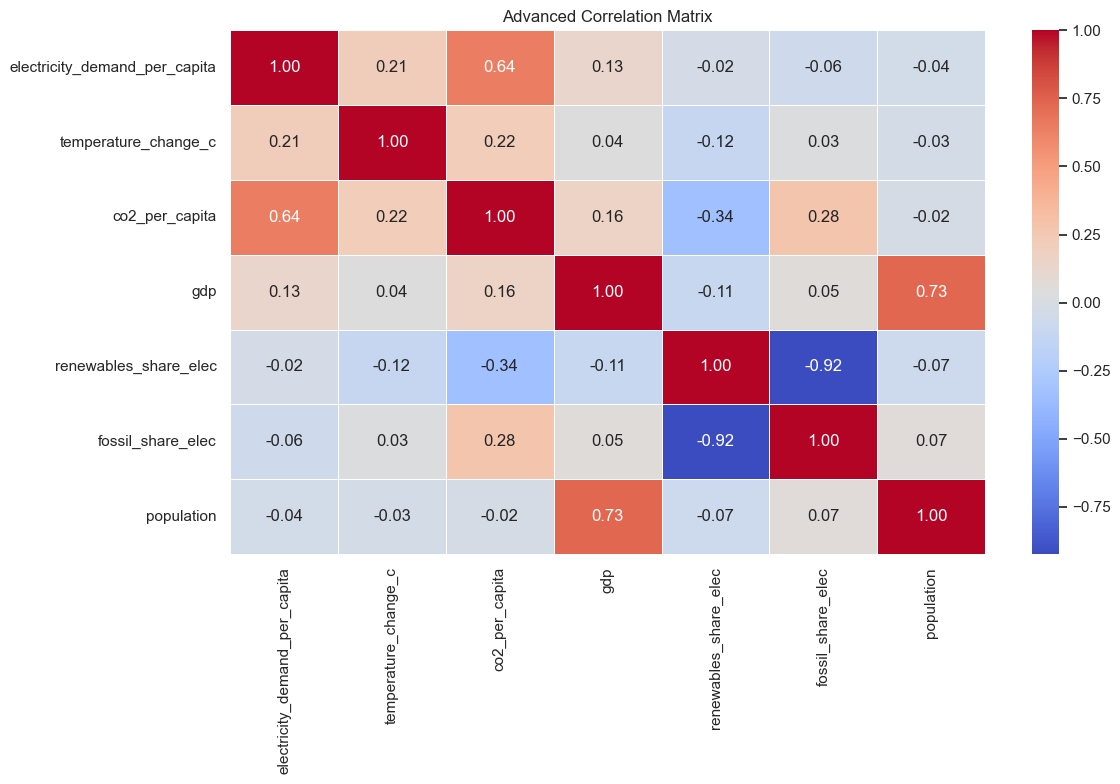

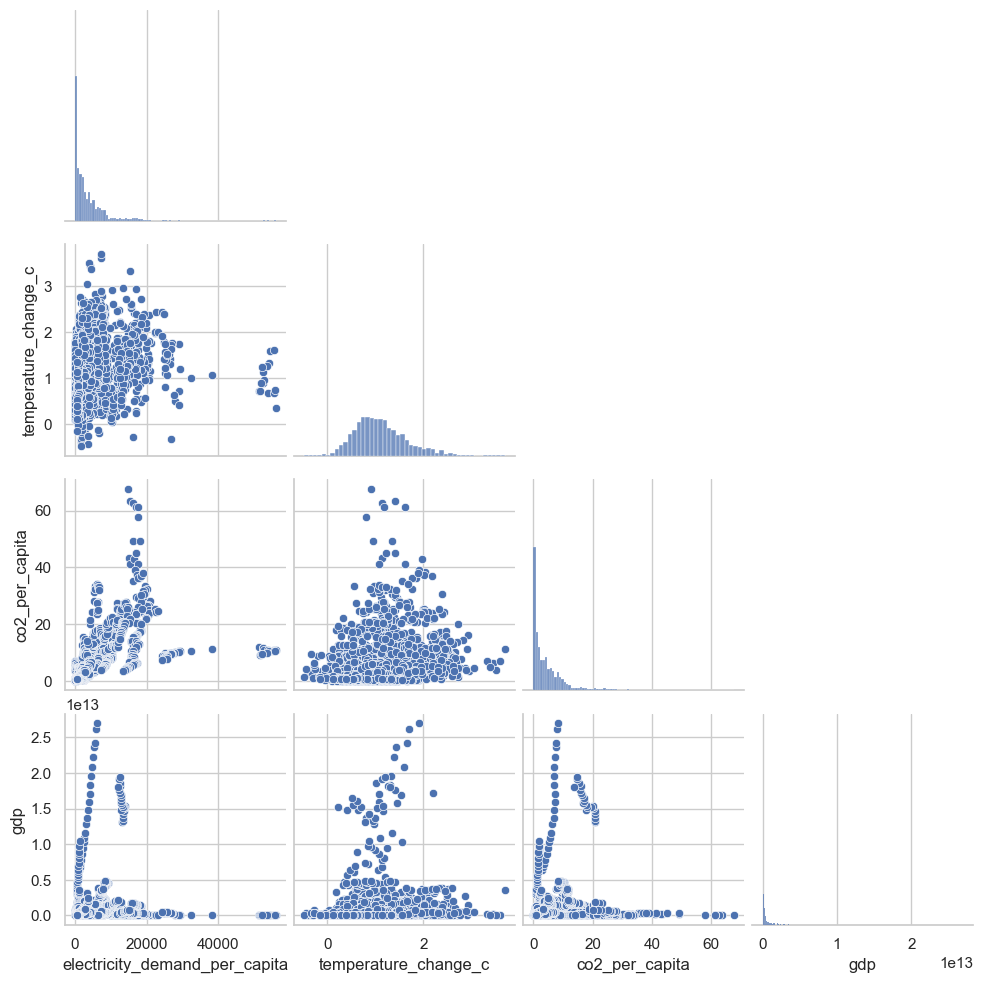

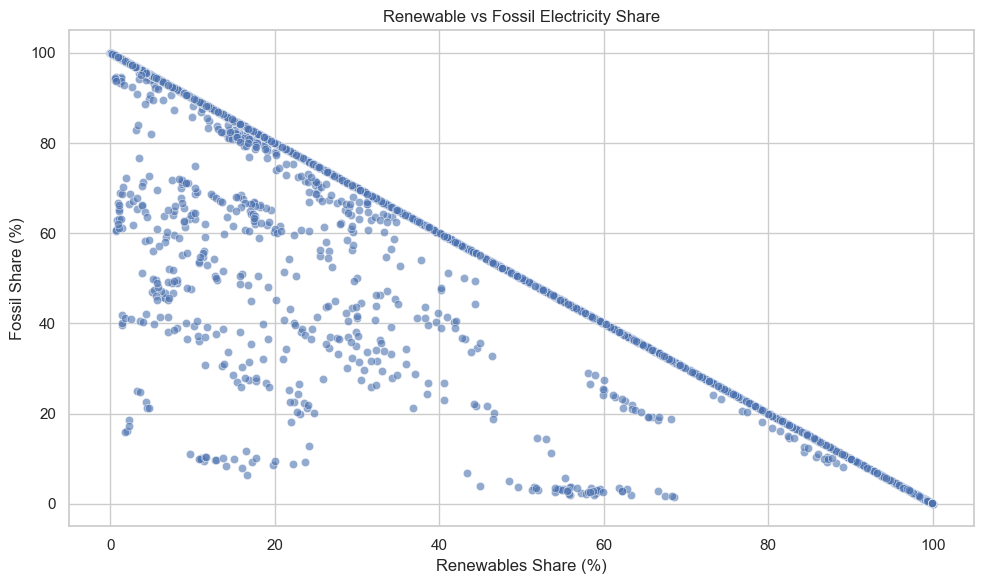

C:\Users\krish\AppData\Local\Temp\ipykernel_36744\4156080731.py:143: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\krish\AppData\Local\Temp\ipykernel_36744\4156080731.py:145: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.savefig(
c:\Users\krish\PyCharmMiscProject\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


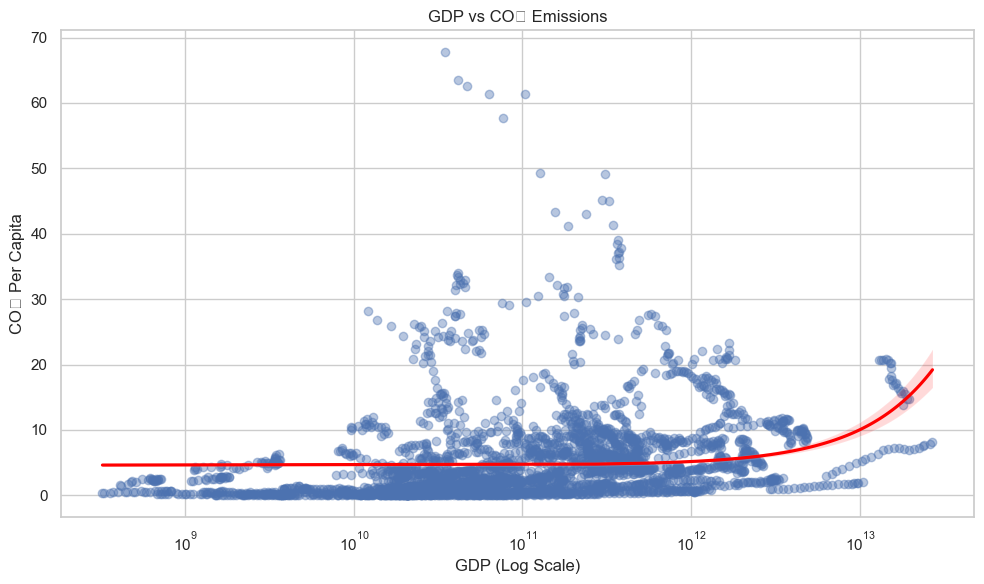


Strongest relationships with electricity demand:
electricity_demand_per_capita    1.000000
co2_per_capita                   0.642631
temperature_change_c             0.209991
gdp                              0.132366
renewables_share_elec           -0.022120
population                      -0.041379
fossil_share_elec               -0.063980
Name: electricity_demand_per_capita, dtype: float64

US-4 Task #39 completed successfully.
Outputs saved in:
../reports/us4_relationship_analysis/


In [ ]:
# ============================================================
# Advanced Correlation Analysis
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# ------------------------------------------------------------
# Create output folder
# ------------------------------------------------------------

US4_REPORTS_DIR = Path("../reports/us4_relationship_analysis")
US4_REPORTS_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")

# ------------------------------------------------------------
# Select variables for advanced analysis
# ------------------------------------------------------------

relationship_columns = [
    "electricity_demand_per_capita",
    "temperature_change_c",
    "co2_per_capita",
    "gdp",
    "renewables_share_elec",
    "fossil_share_elec",
    "population"
]

us4_df = us3_trend_df[relationship_columns].copy()

print("=" * 80)
print("US-4 RELATIONSHIP ANALYSIS")
print("=" * 80)

print("\nDataset Shape:", us4_df.shape)

# ------------------------------------------------------------
# Correlation Matrix
# ------------------------------------------------------------

advanced_corr_matrix = us4_df.corr()

print("\nCorrelation Matrix:")
print(advanced_corr_matrix)

# ------------------------------------------------------------
# Advanced Correlation Heatmap
# ------------------------------------------------------------

plt.figure(figsize=(12, 8))

sns.heatmap(
    advanced_corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Advanced Correlation Matrix")

plt.tight_layout()

plt.savefig(
    US4_REPORTS_DIR / "01_advanced_correlation_heatmap.png",
    dpi=300
)

plt.show()

# ------------------------------------------------------------
# Pairplot Analysis
# ------------------------------------------------------------

pairplot_columns = [
    "electricity_demand_per_capita",
    "temperature_change_c",
    "co2_per_capita",
    "gdp"
]

sns.pairplot(
    us3_trend_df[pairplot_columns],
    corner=True
)

plt.savefig(
    US4_REPORTS_DIR / "02_pairplot_relationships.png",
    dpi=300
)

plt.show()

# ------------------------------------------------------------
# Renewable vs Fossil Energy Relationship
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=us3_trend_df,
    x="renewables_share_elec",
    y="fossil_share_elec",
    alpha=0.6
)

plt.title("Renewable vs Fossil Electricity Share")
plt.xlabel("Renewables Share (%)")
plt.ylabel("Fossil Share (%)")

plt.tight_layout()

plt.savefig(
    US4_REPORTS_DIR / "03_renewable_vs_fossil.png",
    dpi=300
)

plt.show()

# ------------------------------------------------------------
# GDP vs CO2 Relationship
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

sns.regplot(
    data=us3_trend_df,
    x="gdp",
    y="co2_per_capita",
    scatter_kws={"alpha": 0.4},
    line_kws={"color": "red"}
)

plt.xscale("log")

plt.title("GDP vs CO₂ Emissions")
plt.xlabel("GDP (Log Scale)")
plt.ylabel("CO₂ Per Capita")

plt.tight_layout()

plt.savefig(
    US4_REPORTS_DIR / "04_gdp_vs_co2.png",
    dpi=300
)

plt.show()

# ------------------------------------------------------------
# Strongest Correlations
# ------------------------------------------------------------

electricity_corr = (
    advanced_corr_matrix[
        "electricity_demand_per_capita"
    ]
    .sort_values(ascending=False)
)

print("\nStrongest relationships with electricity demand:")
print(electricity_corr)

# ------------------------------------------------------------
# Save Correlation Matrix
# ------------------------------------------------------------

advanced_corr_matrix.to_csv(
    "../data/processed/us4_advanced_correlation_matrix.csv"
)



Country-level dataset prepared
Shape: (152, 8)


,country,electricity_demand_per_capita,temperature_change_c,co2_per_capita,gdp,renewables_share_elec,fossil_share_elec,population
0,Afghanistan,108.781380,1.111773,0.207722,4.739829e+10,80.694249,19.305752,3.039633e+07
1,Albania,2363.336148,1.253591,1.571962,2.662463e+10,98.980810,1.019190,2.963082e+06
2,Algeria,1407.061734,1.398045,3.517347,4.535872e+11,0.754983,99.245016,3.773238e+07
3,Angola,281.032282,0.747364,0.849451,1.179892e+11,70.133126,29.866874,2.525371e+07
4,Argentina,3167.851130,0.525136,4.167413,7.351142e+11,28.473861,65.567386,4.186470e+07


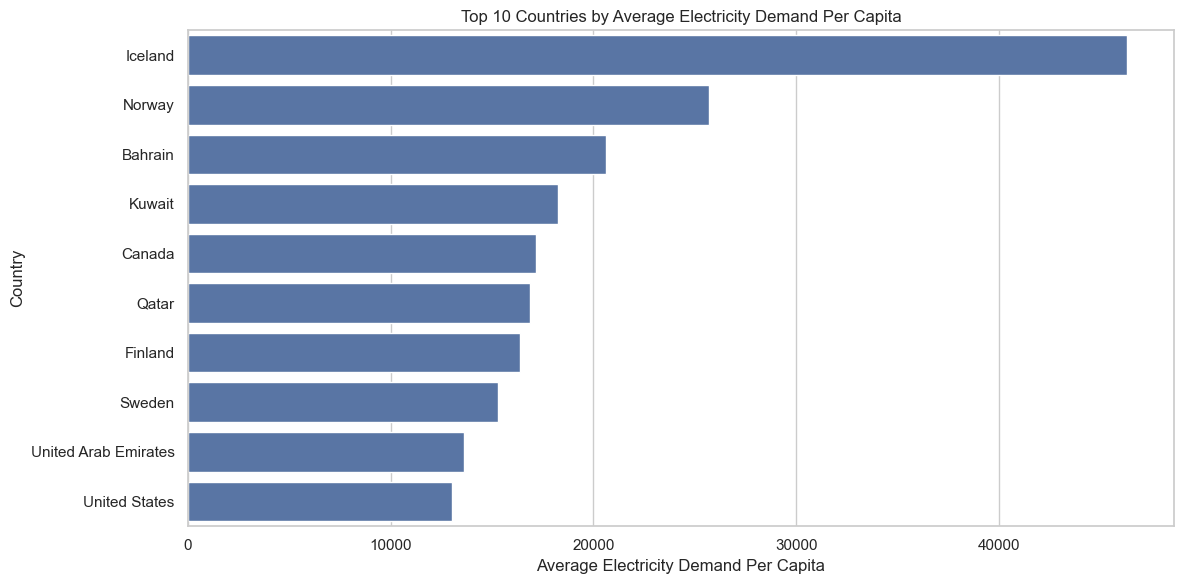

C:\Users\krish\AppData\Local\Temp\ipykernel_36744\3660846784.py:68: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\krish\AppData\Local\Temp\ipykernel_36744\3660846784.py:69: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.savefig("../reports/us4_relationship_analysis/06_country_co2_vs_demand.png", dpi=300)
c:\Users\krish\PyCharmMiscProject\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


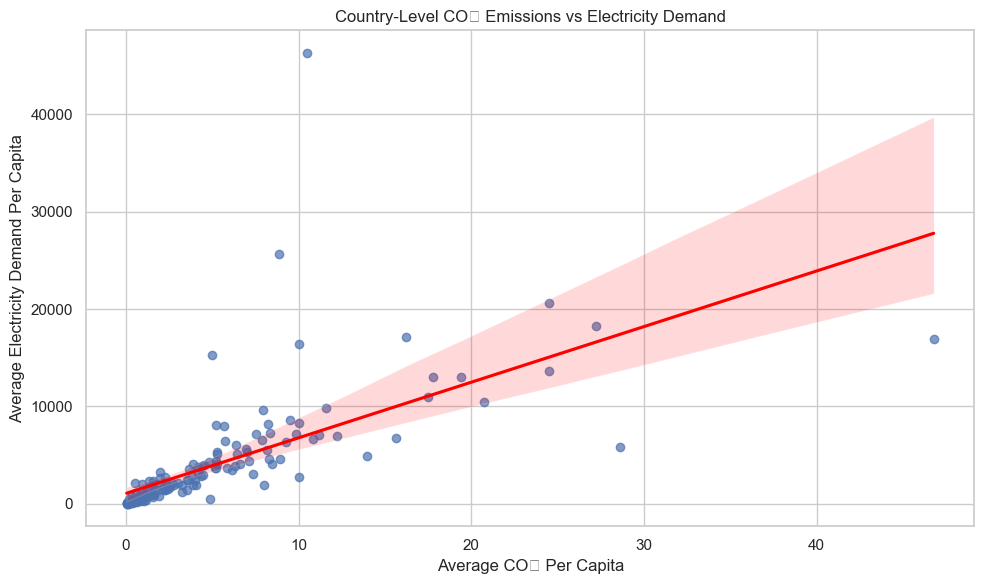

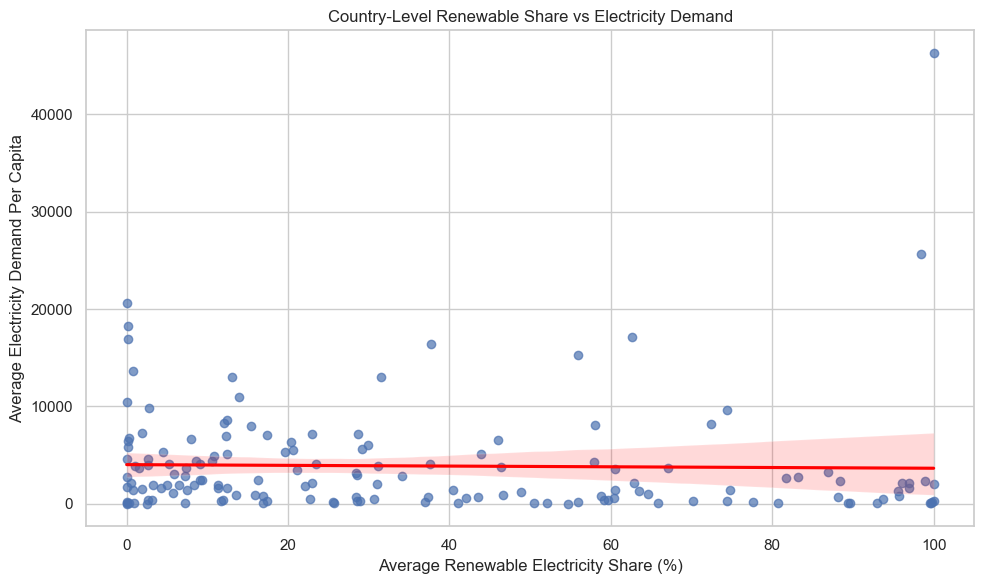

In [6]:
# ------------------------------------------------------------
# Country-level averages
# ------------------------------------------------------------

country_relationships = (
    us3_trend_df
    .groupby("country", as_index=False)
    .agg({
        "electricity_demand_per_capita": "mean",
        "temperature_change_c": "mean",
        "co2_per_capita": "mean",
        "gdp": "mean",
        "renewables_share_elec": "mean",
        "fossil_share_elec": "mean",
        "population": "mean"
    })
)

print("Country-level dataset prepared")
print("Shape:", country_relationships.shape)

display(country_relationships.head())

# ------------------------------------------------------------
# Top 10 countries by electricity demand
# ------------------------------------------------------------

top_10_demand = country_relationships.sort_values(
    by="electricity_demand_per_capita",
    ascending=False
).head(10)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_10_demand,
    x="electricity_demand_per_capita",
    y="country"
)

plt.title("Top 10 Countries by Average Electricity Demand Per Capita")
plt.xlabel("Average Electricity Demand Per Capita")
plt.ylabel("Country")

plt.tight_layout()
plt.savefig("../reports/us4_relationship_analysis/05_top_10_countries_by_demand.png", dpi=300)

plt.show()

# ------------------------------------------------------------
# CO2 vs electricity demand
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

sns.regplot(
    data=country_relationships,
    x="co2_per_capita",
    y="electricity_demand_per_capita",
    scatter_kws={"alpha": 0.7},
    line_kws={"color": "red"}
)

plt.title("Country-Level CO₂ Emissions vs Electricity Demand")
plt.xlabel("Average CO₂ Per Capita")
plt.ylabel("Average Electricity Demand Per Capita")

plt.tight_layout()
plt.savefig("../reports/us4_relationship_analysis/06_country_co2_vs_demand.png", dpi=300)

plt.show()

# ------------------------------------------------------------
# Renewable share vs electricity demand
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

sns.regplot(
    data=country_relationships,
    x="renewables_share_elec",
    y="electricity_demand_per_capita",
    scatter_kws={"alpha": 0.7},
    line_kws={"color": "red"}
)

plt.title("Country-Level Renewable Share vs Electricity Demand")
plt.xlabel("Average Renewable Electricity Share (%)")
plt.ylabel("Average Electricity Demand Per Capita")

plt.tight_layout()
plt.savefig("../reports/us4_relationship_analysis/07_country_renewables_vs_demand.png", dpi=300)

plt.show()

# ------------------------------------------------------------
# Save dataset
# ------------------------------------------------------------

country_relationships.to_csv(
    "../data/processed/us4_country_relationship_analysis.csv",
    index=False
)
